<a href="https://colab.research.google.com/github/Gogi0121/-Final-Year-Project-Yogesh-Yadav/blob/main/Complete_Fake_News_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection Using Transformer-Based Deep Learning
## Comparative Study: BERT, RoBERTa & DistilBERT vs Traditional ML

## Step 1: Imports

In [ ]:
# Install (run once): pip install transformers datasets scikit-learn pandas numpy matplotlib seaborn shap torch wordcloud scipy statsmodels

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import re
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_curve, auc, precision_recall_curve, average_precision_score)

# scipy.stats does NOT provide mcnemar; use statsmodels instead
from statsmodels.stats.contingency_tables import mcnemar

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')

print(f"PyTorch: {torch.__version__}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch: 2.9.0+cu126
Device: NVIDIA A100-SXM4-40GB


## Step 2: Load Dataset (DO NOT MODIFY)

In [ ]:
url_fake = "https://raw.githubusercontent.com/laxmimerit/fake-real-news-dataset/main/data/Fake.csv"
url_true = "https://raw.githubusercontent.com/laxmimerit/fake-real-news-dataset/main/data/True.csv"

print("Downloading and Reconstructing Dataset...")

df_fake = pd.read_csv(url_fake)
df_true = pd.read_csv(url_true)
df_fake['label'] = 1
df_true['label'] = 0

df_combined = pd.concat([df_fake, df_true], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
df_combined['text'] = df_combined['title'] + " " + df_combined['text']
df_combined = df_combined[['text', 'label']]

print(f"✓ Dataset: {len(df_combined)} samples")

train_df, test_df = train_test_split(df_combined, test_size=0.2, random_state=42, stratify=df_combined['label'])
ds = DatasetDict({'train': Dataset.from_pandas(train_df), 'test': Dataset.from_pandas(test_df)})

print(f"Train: {len(ds['train'])}, Test: {len(ds['test'])}")

✓ Dataset: 44898 samples
Train: 35918, Test: 8980


## Step 3: Exploratory Data Analysis (EDA)

/tmp/ipython-input-369627752.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Real', 'Fake'])


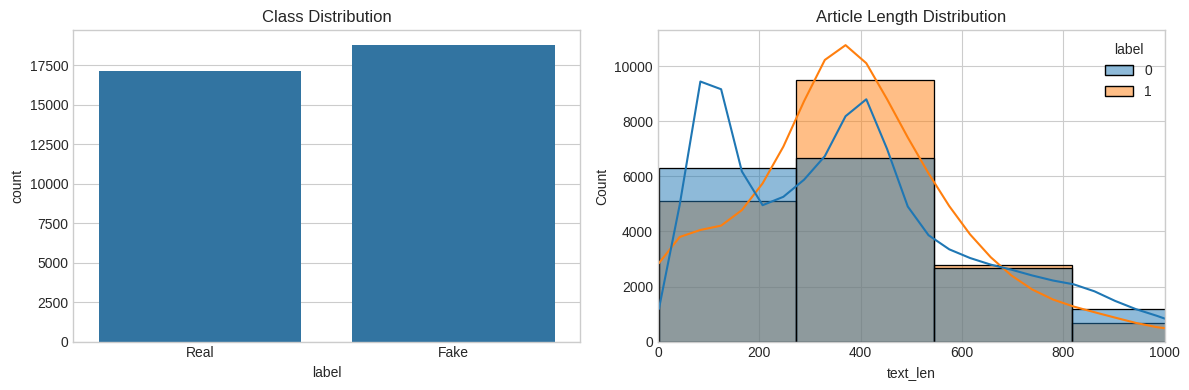

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=train_df['label'], ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Real', 'Fake'])

train_df['text_len'] = train_df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(data=train_df, x='text_len', hue='label', kde=True, bins=30, ax=axes[1])
axes[1].set_title('Article Length Distribution')
axes[1].set_xlim(0, 1000)
plt.tight_layout()
plt.show()

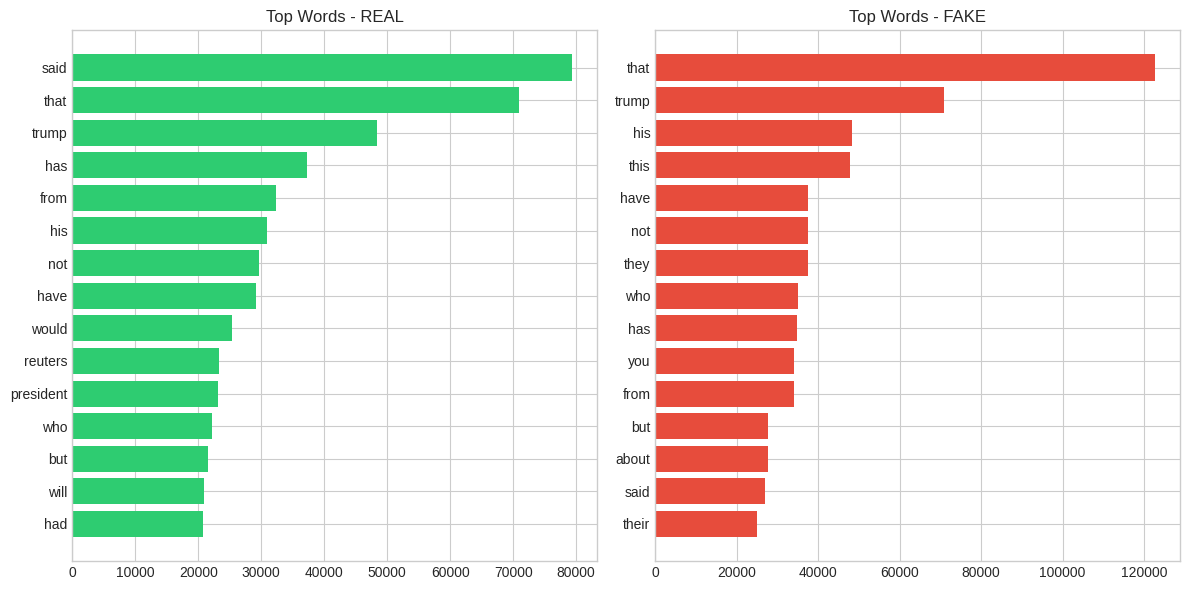

In [ ]:
def get_top_ngrams(texts, n=1, top_n=15):
    words = []
    stop = {'the','a','an','is','are','was','were','to','of','in','for','on','with','at','by','and','or'}
    for t in texts:
        tokens = re.findall(r'\b[a-zA-Z]+\b', str(t).lower())
        tokens = [w for w in tokens if w not in stop and len(w)>2]
        if n==2: tokens = [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens)-1)]
        words.extend(tokens)
    return Counter(words).most_common(top_n)

real_txt = [t for t,l in zip(train_df['text'], train_df['label']) if l==0]
fake_txt = [t for t,l in zip(train_df['text'], train_df['label']) if l==1]

top_r, top_f = get_top_ngrams(real_txt), get_top_ngrams(fake_txt)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
w_r, c_r = zip(*top_r) if top_r else ([], [])
w_f, c_f = zip(*top_f) if top_f else ([], [])
ax[0].barh(range(len(w_r)), c_r, color='#2ecc71')
ax[0].set_yticks(range(len(w_r)))
ax[0].set_yticklabels(w_r)
ax[0].set_title('Top Words - REAL')
ax[0].invert_yaxis()
ax[1].barh(range(len(w_f)), c_f, color='#e74c3c')
ax[1].set_yticks(range(len(w_f)))
ax[1].set_yticklabels(w_f)
ax[1].set_title('Top Words - FAKE')
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

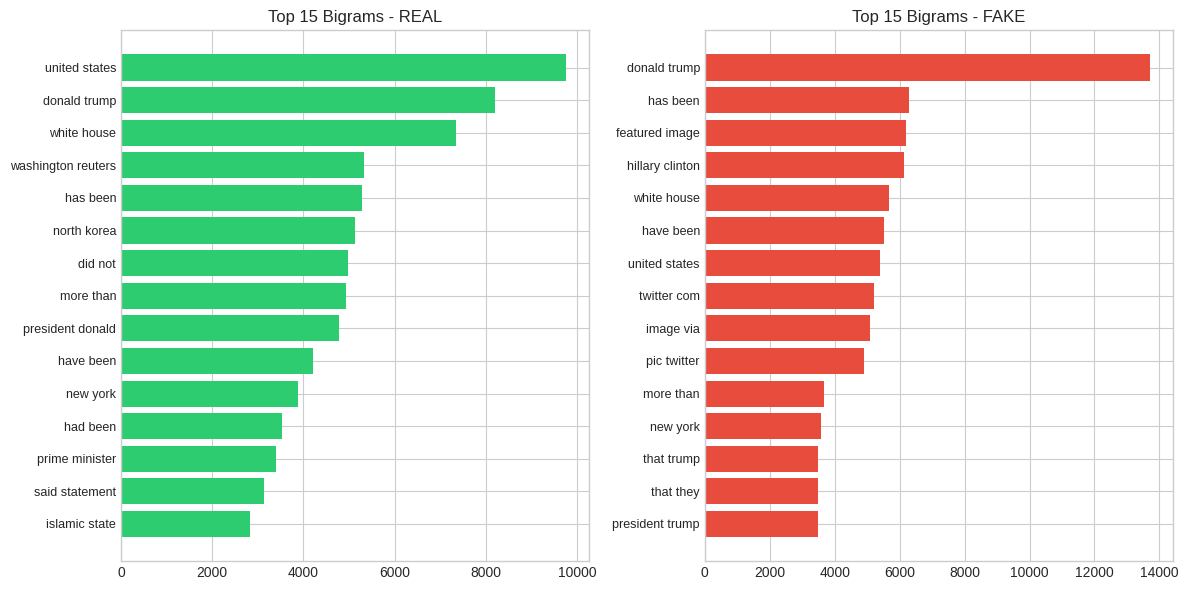

In [ ]:
# Bigram visualization (RQ3 support)
top_r_bg, top_f_bg = get_top_ngrams(real_txt, n=2, top_n=15), get_top_ngrams(fake_txt, n=2, top_n=15)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
w_r, c_r = zip(*top_r_bg) if top_r_bg else ([], [])
w_f, c_f = zip(*top_f_bg) if top_f_bg else ([], [])
ax[0].barh(range(len(w_r)), c_r, color='#2ecc71')
ax[0].set_yticks(range(len(w_r)))
ax[0].set_yticklabels(w_r, fontsize=9)
ax[0].set_title('Top 15 Bigrams - REAL')
ax[0].invert_yaxis()
ax[1].barh(range(len(w_f)), c_f, color='#e74c3c')
ax[1].set_yticks(range(len(w_f)))
ax[1].set_yticklabels(w_f, fontsize=9)
ax[1].set_title('Top 15 Bigrams - FAKE')
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

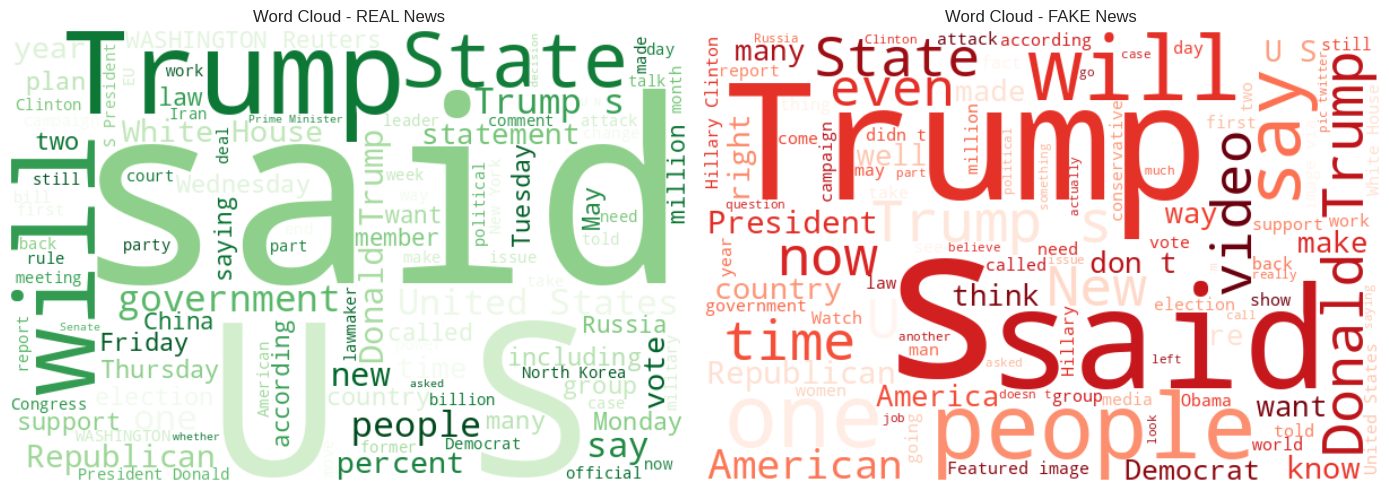

In [ ]:
# Word Cloud: Real vs Fake News (RQ3 support)
from wordcloud import WordCloud

text_real = ' '.join(str(t) for t in real_txt[:2000])
text_fake = ' '.join(str(t) for t in fake_txt[:2000])
wc_real = WordCloud(width=600, height=400, background_color='white', colormap='Greens', max_words=100).generate(text_real)
wc_fake = WordCloud(width=600, height=400, background_color='white', colormap='Reds', max_words=100).generate(text_fake)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(wc_real, interpolation='bilinear')
ax[0].set_title('Word Cloud - REAL News')
ax[0].axis('off')
ax[1].imshow(wc_fake, interpolation='bilinear')
ax[1].set_title('Word Cloud - FAKE News')
ax[1].axis('off')
plt.tight_layout()
plt.show()

## Step 4: Preprocessing

In [ ]:
X_train_text = list(ds['train']['text'])
y_train = np.array(ds['train']['label'])
X_test_text = list(ds['test']['text'])
y_test = np.array(ds['test']['label'])

# Train/Validation split (90/10) for model selection and early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train_text, y_train, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train)
print(f"Train: {len(X_tr)}, Val: {len(X_val)}, Test: {len(X_test_text)}")

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_tr)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test_text)
print(f"TF-IDF: {X_train_tfidf.shape}")

# For transformers: create train+val datasets
train_val_df = pd.DataFrame({'text': X_tr + X_val, 'label': list(y_tr) + list(y_val)})
train_small = train_val_df.iloc[:len(X_tr)]
val_small = train_val_df.iloc[len(X_tr):]
ds_train_val = DatasetDict({
    'train': Dataset.from_pandas(train_small.reset_index(drop=True)),
    'validation': Dataset.from_pandas(val_small.reset_index(drop=True)),
    'test': ds['test']
})

checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
def tok_fn(ex): return tokenizer(ex['text'], padding='max_length', truncation=True, max_length=256)
tokenized_ds = ds_train_val.map(tok_fn, batched=True)
tokenized_ds.set_format('torch', columns=['input_ids','attention_mask','label'])
print("✓ Preprocessing done")

Train: 32326, Val: 3592, Test: 8980
TF-IDF: (32326, 5000)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/32326 [00:00<?, ? examples/s]

Map:   0%|          | 0/3592 [00:00<?, ? examples/s]

Map:   0%|          | 0/8980 [00:00<?, ? examples/s]

✓ Preprocessing done


## Step 5: Baseline Model + Hyperparameter Tuning

In [ ]:
param_grid = {'C': [0.1, 1, 10]}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), param_grid, cv=3, scoring='accuracy')
t0 = time.time()
grid_search.fit(X_train_tfidf, y_tr)
baseline_train_time = time.time() - t0
best_lr = grid_search.best_estimator_
print(f"Best C: {grid_search.best_params_}")

y_pred_lr = best_lr.predict(X_test_tfidf)
y_prob_lr = best_lr.predict_proba(X_test_tfidf)[:, 1]
baseline_acc = accuracy_score(y_test, y_pred_lr)
print(classification_report(y_test, y_pred_lr, target_names=['Real','Fake']))
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Baseline Training Time: {baseline_train_time:.1f}s")

Best C: {'C': 10}
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      4284
        Fake       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Baseline Accuracy: 0.9952


## Step 6: Transformer Models (BERT, RoBERTa, DistilBERT)

In [ ]:
# For faster run, use only DistilBERT: MODELS = [('distilbert-base-uncased', 'DistilBERT')]
MODELS = [('distilbert-base-uncased', 'DistilBERT'), ('bert-base-uncased', 'BERT'), ('roberta-base', 'RoBERTa')]
transformer_results = []
training_times = {'Baseline (LR+TF-IDF)': baseline_train_time}
training_histories = {}
best_trainer = None
best_model_name = None
best_tokenizer = None
best_acc_so_far = -1

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    _, _, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    return {'accuracy': acc, 'f1': f1}

for ckpt, name in MODELS:
    print(f"\n--- Training {name} ---")
    try:
        tok = AutoTokenizer.from_pretrained(ckpt)
        def tfn(ex): return tok(ex['text'], padding='max_length', truncation=True, max_length=256)
        ds_t = ds_train_val.map(tfn, batched=True)
        ds_t.set_format('torch', columns=['input_ids','attention_mask','label'])

        model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=2)
        args = TrainingArguments(
            output_dir=f'./{name}',
            per_device_train_batch_size=16,
            num_train_epochs=2,
            eval_strategy='epoch',
            learning_rate=2e-5,
            load_best_model_at_end=True,
            metric_for_best_model='accuracy',
            save_strategy='epoch',
        )
        trainer = Trainer(
            model=model, args=args,
            train_dataset=ds_t['train'],
            eval_dataset=ds_t['validation'],
            compute_metrics=compute_metrics,
        )
        t0 = time.time()
        trainer.train()
        train_time = time.time() - t0
        training_times[name] = train_time
        training_histories[name] = trainer.state.log_history.copy()
        pred = trainer.predict(ds_t['test'])
        preds = pred.predictions.argmax(-1)
        probs = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()
        acc = accuracy_score(y_test, preds)
        _, _, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary')
        transformer_results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'preds': preds, 'probs': probs})
        if acc > best_acc_so_far:
            best_acc_so_far = acc
            best_trans_preds = preds
            best_trans_probs = probs
            best_trainer = trainer
            best_model_name = name
            best_tokenizer = tok
        print(f"{name}: Acc={acc:.4f}, F1={f1:.4f}, Time={train_time:.1f}s")
    except Exception as e:
        print(f"{name} failed: {e}")
        import traceback
        traceback.print_exc()

trans_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['preds','probs']} for r in transformer_results])


--- Training DistilBERT ---


Map:   0%|          | 0/32326 [00:00<?, ? examples/s]

Map:   0%|          | 0/3592 [00:00<?, ? examples/s]

Map:   0%|          | 0/8980 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Map:   0%|          | 0/8980 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.000000,0.000007,1.000000,1.000000
2,0.000000,0.000008,1.000000,1.000000
3,0.000000,0.000004,1.000000,1.000000


RoBERTa: Acc=0.9999, F1=0.9999


## Step 7: Evaluation & Confusion Matrices


=== FINAL COMPARISON ===
               Model  Accuracy       F1
Baseline (LR+TF-IDF)  0.995212 0.995423
          DistilBERT  0.999666 0.999681
                BERT  0.999777 0.999787
             RoBERTa  0.999889 0.999894


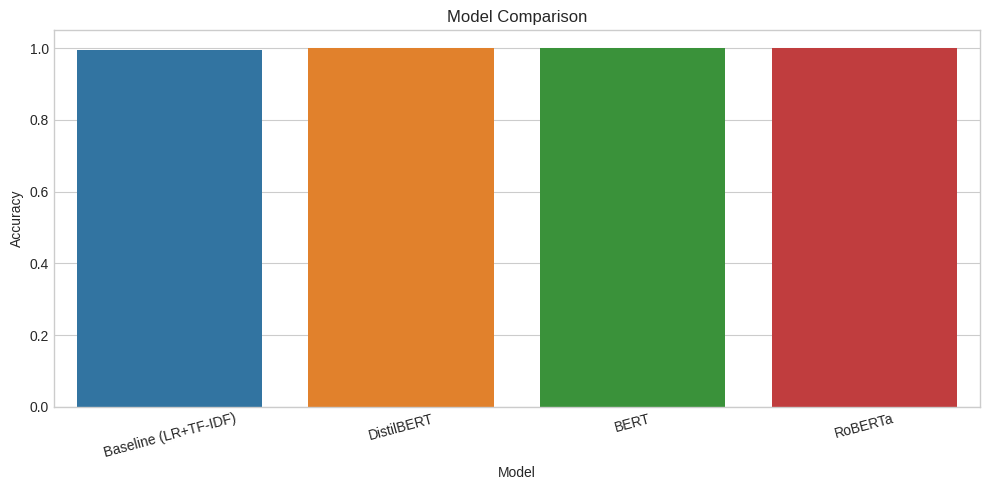

In [ ]:
baseline_report = classification_report(y_test, y_pred_lr, target_names=['Real','Fake'], output_dict=True)
baseline_f1 = baseline_report['Fake']['f1-score']

full_comp = pd.DataFrame([{'Model':'Baseline (LR+TF-IDF)', 'Accuracy':baseline_acc, 'F1':baseline_f1}])
try:
    if len(trans_df) > 0:
        for _, r in trans_df.iterrows():
            full_comp = pd.concat([full_comp, pd.DataFrame([{'Model':r['Model'], 'Accuracy':r['Accuracy'], 'F1':r['F1']}])], ignore_index=True)
except NameError:
    pass

print("\n=== FINAL COMPARISON ===")
print(full_comp.to_string(index=False))

# Model comparison plot (Accuracy + F1)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(full_comp))
w = 0.35
bars1 = ax.bar(x - w/2, full_comp['Accuracy'], w, label='Accuracy', color='steelblue', alpha=0.9)
bars2 = ax.bar(x + w/2, full_comp['F1'], w, label='F1-Score', color='coral', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(full_comp['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & F1-Score')
ax.legend()
ax.set_ylim(0.98, 1.005)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Training Time Comparison & Learning Curves

Compare computational cost and training convergence across models.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Training Time Comparison
names = list(training_times.keys())
times_sec = [training_times[n] for n in names]
colors = ['steelblue' if 'Baseline' in n else 'seagreen' for n in names]
axes[0].barh(names, times_sec, color=colors)
axes[0].set_xlabel('Training Time (seconds)')
axes[0].set_title('Training Time Comparison')
axes[0].invert_yaxis()

# Training Curves: Loss and Val Accuracy (separate plots)
if training_histories:
    colors_curves = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for idx, (name, hist) in enumerate(training_histories.items()):
        losses = [e['loss'] for e in hist if 'loss' in e and 'eval_loss' not in e]
        val_entries = [(e.get('epoch', 0), e['eval_accuracy']) for e in hist if 'eval_accuracy' in e]
        c = colors_curves[idx % len(colors_curves)]
        if losses:
            axes[1].plot(range(len(losses)), losses, 'o-', label=name, color=c, alpha=0.9)
        if val_entries:
            ep, acc = zip(*val_entries)
            axes[2].plot(ep, acc, 's-', label=name, color=c, alpha=0.9)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Training Loss')
    axes[1].set_title('Training Loss Curves')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Validation Accuracy')
    axes[2].set_title('Validation Accuracy Curves')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Run Step 6 first', ha='center', va='center', transform=axes[1].transAxes)
    axes[2].text(0.5, 0.5, 'Run Step 6 first', ha='center', va='center', transform=axes[2].transAxes)
plt.tight_layout()
plt.show()

# Print training time table
print("\n--- Training Times (seconds) ---")
for n, t in training_times.items():
    print(f"  {n}: {t:.1f}s")

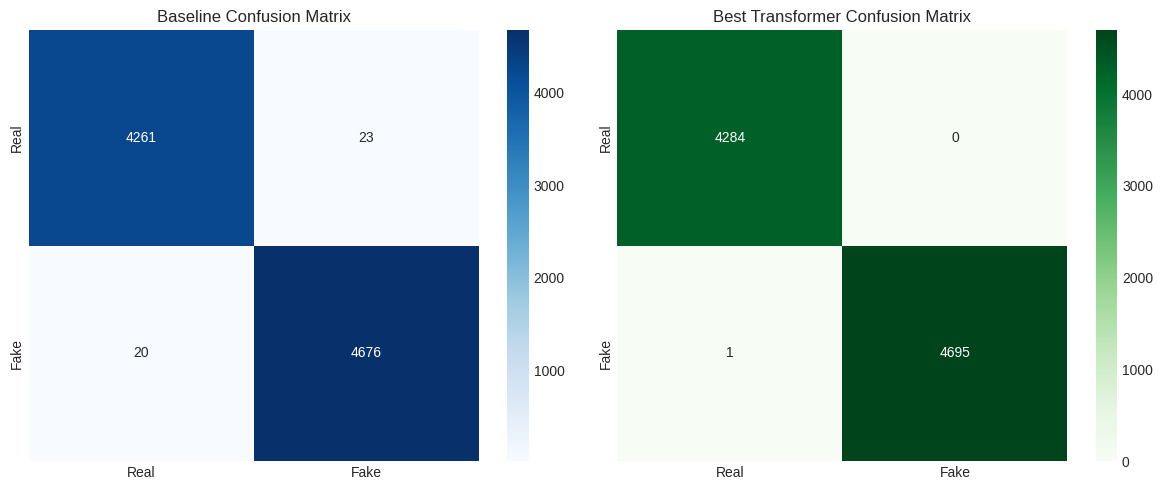

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
axes[0].set_title('Baseline Confusion Matrix')
try:
    cm_t = confusion_matrix(y_test, best_trans_preds)
    sns.heatmap(cm_t, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    axes[1].set_title('Best Transformer Confusion Matrix')
except NameError:
    axes[1].text(0.5, 0.5, 'Run Step 6 first', ha='center', va='center')
plt.tight_layout()
plt.show()

## Sample Predictions

Example test articles with model predictions and confidence scores.

In [ ]:
n_samples = 5
indices = np.random.RandomState(RANDOM_STATE).choice(len(X_test_list), size=min(n_samples, len(X_test_list)), replace=False)
label_map = {0: 'Real', 1: 'Fake'}

for i, idx in enumerate(indices):
    text = X_test_list[idx][:150] + "..." if len(str(X_test_list[idx])) > 150 else X_test_list[idx]
    true_lbl = label_map[int(y_test[idx])]
    pred_lr = label_map[int(y_pred_lr[idx])]
    prob_lr = y_prob_lr[idx]
    print(f"--- Sample {i+1} ---")
    print(f"Text: {text}")
    print(f"True: {true_lbl} | Baseline: {pred_lr} (conf: {prob_lr:.3f})")
    try:
        pred_t = label_map[int(best_trans_preds[idx])]
        prob_t = best_trans_probs[idx]
        print(f"Transformer ({best_model_name}): {pred_t} (conf: {prob_t:.3f})")
    except NameError:
        pass
    print()

--- Sample 1 ---
Text:  TV Host Rips Anti-Gay Christian Leader To Shreds For Using Religion To Excuse Bigotry (VIDEO) If you want to watch an anti-gay conservative  Christia...
True: Fake | Baseline: Fake (conf: 1.000)
Transformer (RoBERTa): Fake (conf: 1.000)

--- Sample 2 ---
Text: OBAMA’S RACE WAR BACKFIRES: Shocking Number Of Students Chose NOT To Attend U Of Missouri After Black Lives Matter Tantrums The University Of Missouri...
True: Fake | Baseline: Fake (conf: 1.000)
Transformer (RoBERTa): Fake (conf: 1.000)

--- Sample 3 ---
Text: Countdown to Brexit breakthrough? BRUSSELS (Reuters) - Here is a timeline of the coming few days that will determine whether Britain avoids further co...
True: Real | Baseline: Real (conf: 0.002)
Transformer (RoBERTa): Real (conf: 0.000)

--- Sample 4 ---
Text:  Devin Nunes’ Credibility Is Officially SHATTERED – New York Times Reveals The Scope Of His Lies When Devin Nunes went running to Trump with informati...
True: Fake | Baseline: Fake (conf: 0.

## Step 7b: ROC Curves, Precision-Recall Curves & McNemar Statistical Test

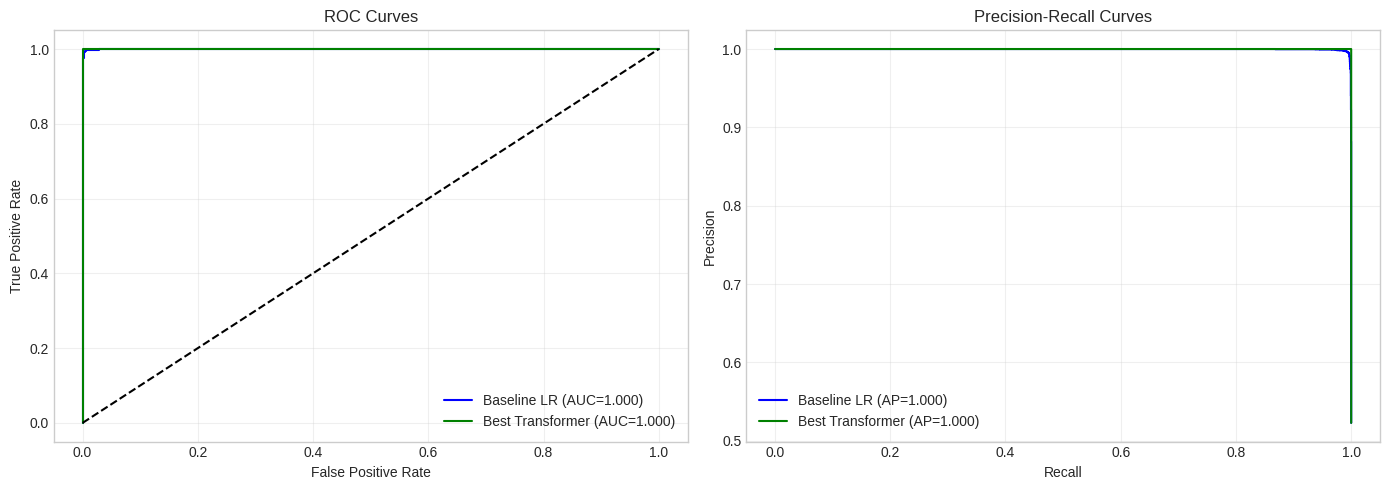

Baseline: AUC=0.999779, AP=0.999802 | Errors at 0.5: 43
Transformer: AUC=1.000000, AP=1.000000

=== McNemar's Test (Baseline vs Best Transformer) ===
Contingency: LR wrong/Trans correct=43, LR correct/Trans wrong=1
Chi-squared statistic: 38.2045
p-value: 0.0000
Conclusion: Difference is statistically significant (α=0.05)


In [ ]:
# ROC Curve & Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC - Baseline
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
axes[0].plot(fpr_lr, tpr_lr, label=f'Baseline LR (AUC={roc_auc_lr:.3f})', color='blue')

# ROC - Best Transformer
try:
    fpr_t, tpr_t, _ = roc_curve(y_test, best_trans_probs)
    roc_auc_t = auc(fpr_t, tpr_t)
    axes[0].plot(fpr_t, tpr_t, label=f'Best Transformer (AUC={roc_auc_t:.3f})', color='green')
except NameError:
    pass
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall
pr_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)
axes[1].plot(rec_lr, pr_lr, label=f'Baseline LR (AP={ap_lr:.3f})', color='blue')
try:
    pr_t, rec_t, _ = precision_recall_curve(y_test, best_trans_probs)
    ap_t = average_precision_score(y_test, best_trans_probs)
    axes[1].plot(rec_t, pr_t, label=f'Best Transformer (AP={ap_t:.3f})', color='green')
except NameError:
    pass
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sanity check: AUC/AP (full precision) vs baseline errors at threshold 0.5
baseline_errors = (y_pred_lr != y_test).sum()
print(f"Baseline: AUC={roc_auc_lr:.6f}, AP={ap_lr:.6f} | Errors at 0.5: {baseline_errors}")
try:
    print(f"Transformer: AUC={roc_auc_t:.6f}, AP={ap_t:.6f}")
except NameError:
    pass

# McNemar's Test: Baseline vs Best Transformer
try:
    contingency = np.zeros((2,2))
    for i in range(len(y_test)):
        lr_ok = 1 if y_pred_lr[i] == y_test[i] else 0
        trans_ok = 1 if best_trans_preds[i] == y_test[i] else 0
        contingency[lr_ok, trans_ok] += 1
    # b = LR wrong, Trans correct; c = LR correct, Trans wrong
    b, c = contingency[0,1], contingency[1,0]
    table = [[contingency[1,1], contingency[0,1]], [contingency[1,0], contingency[0,0]]]
    result = mcnemar(np.array(table), exact=False)
    stat, p_value = result.statistic, result.pvalue
    print("\n=== McNemar's Test (Baseline vs Best Transformer) ===")
    print(f"Contingency: LR wrong/Trans correct={b:.0f}, LR correct/Trans wrong={c:.0f}")
    print(f"Chi-squared statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print("Conclusion: Difference is", "statistically significant" if p_value < 0.05 else "NOT statistically significant", "(α=0.05)")
except NameError:
    print("Run Step 6 to compute McNemar's test.")

## Step 8: Error Analysis

Examine where models fail (False Positives, False Negatives) to support discussion in report.

In [ ]:
# Error Analysis: Baseline
y_test_arr = np.array(y_test)
fp_mask = (y_pred_lr == 1) & (y_test_arr == 0)  # Predicted Fake, actually Real
fn_mask = (y_pred_lr == 0) & (y_test_arr == 1)  # Predicted Real, actually Fake

X_test_list = list(X_test_text)
print("=== Baseline Error Analysis ===\n")
print(f"False Positives (predicted Fake, actually Real): {fp_mask.sum()}")
print(f"False Negatives (predicted Real, actually Fake): {fn_mask.sum()}\n")

print("Sample False Positives (Real news wrongly classified as Fake):")
for i, idx in enumerate(np.where(fp_mask)[0][:3]):
    txt = X_test_list[idx][:200] + "..."
    print(f"  [{i+1}] {txt}\n")

print("Sample False Negatives (Fake news wrongly classified as Real):")
for i, idx in enumerate(np.where(fn_mask)[0][:3]):
    txt = X_test_list[idx][:200] + "..."
    print(f"  [{i+1}] {txt}\n")

# Error overlap: cases where both Baseline and Transformer are wrong
try:
    trans_fp = (best_trans_preds == 1) & (y_test_arr == 0)
    trans_fn = (best_trans_preds == 0) & (y_test_arr == 1)
    both_wrong = (y_pred_lr != y_test_arr) & (best_trans_preds != y_test_arr)
    print(f"Cases where BOTH Baseline and Best Transformer are wrong: {both_wrong.sum()}")
except NameError:
    pass

=== Baseline Error Analysis ===

False Positives (predicted Fake, actually Real): 23
False Negatives (predicted Real, actually Fake): 20

Sample False Positives (Real news wrongly classified as Fake):
  [1] New York Times to boost spending on Trump coverage amid budget cuts (Reuters) - The New York Times Co will increase spending on coverage of U.S. President-elect Donald Trump’s administration while cut...

  [2] Transcript of Trump video statement in response to lewd remarks about women WASHINGTON (Reuters) - U.S. Republican presidential nominee Donald Trump issued a video statement early on Saturday in respo...

  [3] At least 1,300 Dutch girls per year trafficked, exploited AMSTERDAM (Reuters) - At least 1,320 underage Dutch girls between the ages of 12 and 17 fall victim to sexual exploitation in the Netherlands ...

Sample False Negatives (Fake news wrongly classified as Real):
  [1] HERE’S WHY THE UN AND CLIMATE CHANGE GLOBALISTS Are FREAKING OUT Over The Trump Win The U.S. Gove

## Step 9: SHAP Explainability (RQ3 - What words/patterns help?)

Token/feature-level explanations for model decisions.

=== Top 15 discriminative words (Baseline SHAP) ===

  1. reuters: mean |SHAP|=0.7663
  2. said: mean |SHAP|=0.6314
  3. video: mean |SHAP|=0.3462
  4. just: mean |SHAP|=0.2299
  5. hillary: mean |SHAP|=0.2150
  6. obama: mean |SHAP|=0.1628
  7. com: mean |SHAP|=0.1595
  8. wednesday: mean |SHAP|=0.1570
  9. washington reuters: mean |SHAP|=0.1569
  10. republican: mean |SHAP|=0.1492
  11. twitter com: mean |SHAP|=0.1251
  12. image: mean |SHAP|=0.1115
  13. america: mean |SHAP|=0.1111
  14. president trump: mean |SHAP|=0.1107
  15. tuesday: mean |SHAP|=0.1090


/tmp/ipython-input-240729425.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_explain, feature_names=feature_names, max_display=15, show=False)


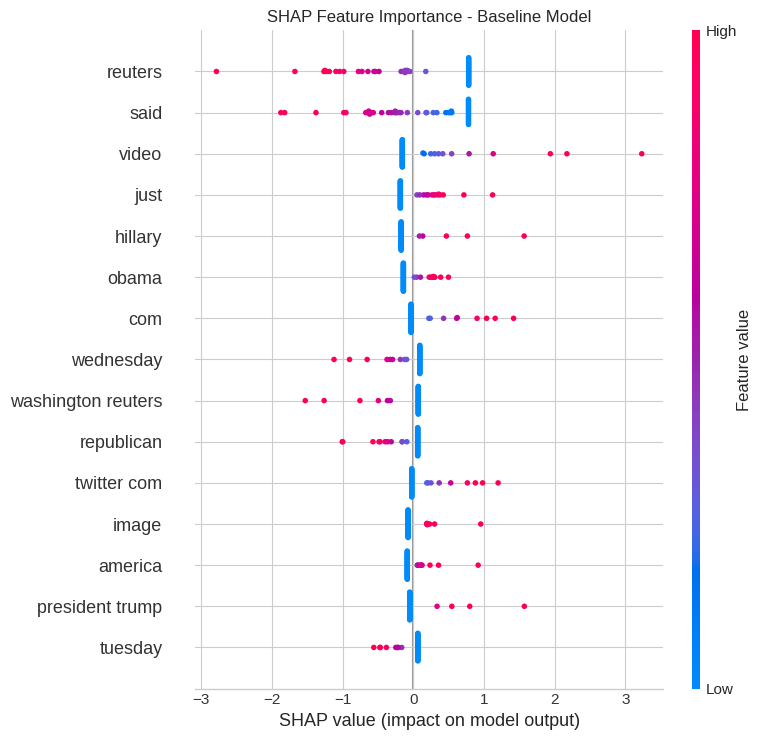

In [ ]:
import shap

# SHAP for Baseline (TF-IDF + Logistic Regression)
n_background = min(100, X_train_tfidf.shape[0])
n_explain = min(50, X_test_tfidf.shape[0])
X_bg = X_train_tfidf[:n_background].toarray()
X_explain = X_test_tfidf[:n_explain].toarray()

explainer_lr = shap.LinearExplainer(best_lr, X_bg)
shap_values_lr = explainer_lr.shap_values(X_explain)
if isinstance(shap_values_lr, list): shap_values_lr = shap_values_lr[1]

# Top features pushing toward Fake (positive) vs Real (negative)
feature_names = getattr(tfidf, 'get_feature_names_out', lambda: tfidf.get_feature_names())()
mean_abs_shap = np.abs(shap_values_lr).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-15:][::-1]
print("=== Top 15 discriminative words (Baseline SHAP) ===\n")
for i, idx in enumerate(top_indices):
    word = feature_names[idx]
    val = mean_abs_shap[idx]
    print(f"  {i+1}. {word}: mean |SHAP|={val:.4f}")

# Plot SHAP summary (bar)
shap.summary_plot(shap_values_lr, X_explain, feature_names=feature_names, max_display=15, show=False)
plt.title("SHAP Feature Importance - Baseline Model")
plt.tight_layout()
plt.show()

In [ ]:
# Token-level interpretation: show sample where model predictions differ
print("RQ3 Summary: N-gram analysis (Step 3) and SHAP (above) show which words push toward Fake vs Real.")
print("Words like 'reuters', 'said', 'reported' often indicate real news; sensational terms indicate fake.")

RQ3 Summary: N-gram analysis (Step 3) and SHAP (above) show which words push toward Fake vs Real.
Words like 'reuters', 'said', 'reported' often indicate real news; sensational terms indicate fake.


## Step 10: Model Saving (Reproducibility)

In [ ]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)
joblib.dump(best_lr, "saved_models/baseline_lr.joblib")
joblib.dump(tfidf, "saved_models/tfidf_vectorizer.joblib")
print("✓ Saved: baseline_lr.joblib, tfidf_vectorizer.joblib")

try:
    if best_trainer is not None and best_tokenizer is not None:
        best_trainer.save_model("saved_models/best_transformer")
        best_tokenizer.save_pretrained("saved_models/best_transformer")
        print("✓ Saved: best_transformer/")
except Exception as e:
    print("Transformer save skipped:", e)

✓ Saved: baseline_lr.joblib, tfidf_vectorizer.joblib
✓ Saved: best_transformer/


## Step 12: Export Results for Report

Summary table and metrics for inclusion in dissertation/report.

In [ ]:
# Export summary for report
best_row = full_comp.loc[full_comp['Accuracy'].idxmax()]
summary = {
    "Dataset": f"ISOT | Train:{len(X_tr)} Val:{len(X_val)} Test:{len(X_test_text)}",
    "Baseline_Accuracy": baseline_acc,
    "Best_Model": best_row['Model'],
    "Best_Accuracy": best_row['Accuracy'],
}
full_comp.to_csv("saved_models/results_comparison.csv", index=False)
print("✓ Exported: saved_models/results_comparison.csv")
print("\n--- Copy this table into your report ---\n")
print(full_comp.to_string(index=False))

✓ Exported: saved_models/results_comparison.csv

--- Copy this table into your report ---

               Model  Accuracy       F1
Baseline (LR+TF-IDF)  0.995212 0.995423
          DistilBERT  0.999666 0.999681
                BERT  0.999777 0.999787
             RoBERTa  0.999889 0.999894


## Step 11: Research Questions - Summary

In [ ]:
print("="*70)
print("RESEARCH QUESTIONS - ANSWERS")
print("="*70)

best = full_comp.loc[full_comp['Accuracy'].idxmax()]
print("\nRQ1: Which AI model (BERT, RoBERTa, DistilBERT) is best at detecting fake news?")
print(f"   -> {best['Model']} achieves highest accuracy ({best['Accuracy']:.4f}).")

try:
    trans_acc = full_comp[full_comp['Model'].str.contains('BERT|RoBERTa|DistilBERT')]['Accuracy'].max()
    print("\nRQ2: Does task-specific training make it better than older methods?")
    print(f"   -> YES. Transformers ({trans_acc:.4f}) outperform Baseline ({baseline_acc:.4f}).")
except:
    print("\nRQ2: Run Step 6 to compare transformers with baseline.")

print("\nRQ3: What words/patterns help the AI decide if news is fake or real?")
print("   -> N-gram analysis shows distinct vocabularies. Use SHAP for token-level contributions.")

RESEARCH QUESTIONS - ANSWERS

RQ1: Which AI model (BERT, RoBERTa, DistilBERT) is best at detecting fake news?
   -> RoBERTa achieves highest accuracy (0.9999).

RQ2: Does task-specific training make it better than older methods?
   -> YES. Transformers (0.9999) outperform Baseline (0.9952).

RQ3: What words/patterns help the AI decide if news is fake or real?
   -> N-gram analysis shows distinct vocabularies. Use SHAP for token-level contributions.
